In [1]:
import pandas as pd
import gspread
from oauth2client.service_account import ServiceAccountCredentials
import os

from utils import GOOGLE_SHEETS, KNOWN_BRANDS

def get_gspread_client(json_path='../credentials.json'):
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"Fisierul de credentiale nu se afla la: {json_path}")
        
    scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/drive"]
    creds = ServiceAccountCredentials.from_json_keyfile_name(json_path, scope)
    return gspread.authorize(creds)

def load_sheet_by_gid(client, sheet_config, page_name, header_row=4):
    try:
        spreadsheet = client.open_by_key(sheet_config.id)
        gid_target = sheet_config.pages.get(page_name)
        if not gid_target:
            raise ValueError(f"Pagina '{page_name}' nu există în config pentru acest raport.")
            
        worksheet = None
        for ws in spreadsheet.worksheets():
            if str(ws.id) == str(gid_target):
                worksheet = ws
                break
        
        if not worksheet:
            raise ValueError(f"Worksheet cu GID: {gid_target} nu exista!")

        print(f"Se descarca datele din '{page_name}'...")
        all_values = worksheet.get_all_values()
        
        if len(all_values) <= header_row:
            raise ValueError("Header gresit sau fisier gol")
            
        headers = all_values[header_row]
        data_rows = all_values[header_row + 1:]
        
        df = pd.DataFrame(data_rows, columns=headers)
        return df

    except Exception as e:
        print(f"Eroare: {e}")
        return None

In [2]:
client = get_gspread_client()

df_pacienti = load_sheet_by_gid(
    client, 
    GOOGLE_SHEETS['Raport_pacienti'], 
    'Pacienti',
    header_row=3 
)

if df_pacienti is not None:
    display(df_pacienti.head())
    print(f"Coloane detectate: {df_pacienti.columns.tolist()}")

Se descarca datele din 'Pacienti'...


,Nume,Prenume,CNP,Telefon,Email,Data prog.,Nr. programari ratate
0,CIRJA,ALINA,0,0745575388,cirja_ionela_alina@yahoo.com,2025-05-30 15:40:00,1
1,ABABEI,CATALIN,1931214045357,0737963664,lavinia.negrei@yahoo.com,2022-11-10 16:00:00,1
2,ABABEI,IOANA,2521003044421,0748818292,,2023-09-28 10:20:00,1
3,ABAGERU,GHEORGHE,1461205044435,0741738839,,2023-06-14 16:45:00,1
4,ABARBOAE,DARIA,,0748033207,,2023-02-08 10:15:00,1


Coloane detectate: ['Nume', 'Prenume', 'CNP', 'Telefon', 'Email', 'Data prog.', 'Nr. programari ratate']


In [3]:
df = df_pacienti.copy()

cols_to_drop = ['Nume', 'Prenume', 'Telefon', 'Email']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

df['Nr. programari ratate'] = pd.to_numeric(df['Nr. programari ratate'], errors='coerce').fillna(0).astype(int)
df['Data prog.'] = pd.to_datetime(df['Data prog.'])

df['CNP'] = df['CNP'].astype(str).str.strip()
df = df[df['CNP'].str.len() == 13].copy()

print("Primele 5 randuri dupa curatare:")
display(df.head())
print(df.info())

Primele 5 randuri dupa curatare:


,CNP,Data prog.,Nr. programari ratate
1,1931214045357,2022-11-10 16:00:00,1
2,2521003044421,2023-09-28 10:20:00,1
3,1461205044435,2023-06-14 16:45:00,1
7,1570420043765,2025-06-20 08:40:00,1
9,2460801044429,2022-02-24 10:45:00,1


<class 'pandas.core.frame.DataFrame'>
Index: 1145 entries, 1 to 2025
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   CNP                    1145 non-null   object        
 1   Data prog.             1145 non-null   datetime64[ns]
 2   Nr. programari ratate  1145 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 35.8+ KB
None


In [4]:
def parse_cnp(cnp_str):
    try:
        s = int(cnp_str[0])
        aa = int(cnp_str[1:3])
        
        if s % 2 == 1:
            gen = 'M'
        else:
            gen = 'F'
            
        if s in [1, 2]: prefix = 1900
        elif s in [5, 6]: prefix = 2000
        elif s in [3, 4]: prefix = 1800
        else: prefix = 1900 
        
        an_nastere = prefix + aa
        
        varsta = 2025 - an_nastere
        
        return pd.Series([gen, varsta])
    except:
        return pd.Series(['Unknown', 0])

df[['gen', 'Varsta']] = df['CNP'].apply(parse_cnp)
df_final = df.drop(columns=['CNP'])

print("Dataset Final Anonimizat:")
display(df_final.head(10))

Dataset Final Anonimizat:


,Data prog.,Nr. programari ratate,gen,Varsta
1,2022-11-10 16:00:00,1,M,32
2,2023-09-28 10:20:00,1,F,73
3,2023-06-14 16:45:00,1,M,79
7,2025-06-20 08:40:00,1,M,68
9,2022-02-24 10:45:00,1,F,79
10,2022-09-08 12:15:00,1,F,22
11,2023-01-27 11:45:00,1,M,65
13,2023-04-28 13:00:00,1,M,61
16,2022-11-23 14:00:00,1,M,77
17,2024-08-08 09:00:00,2,M,80


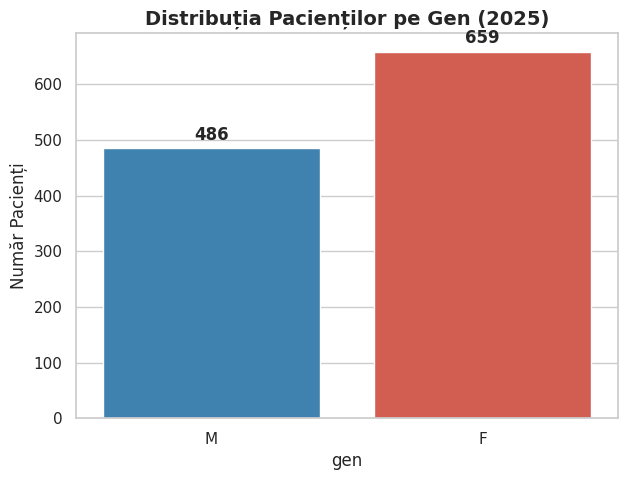

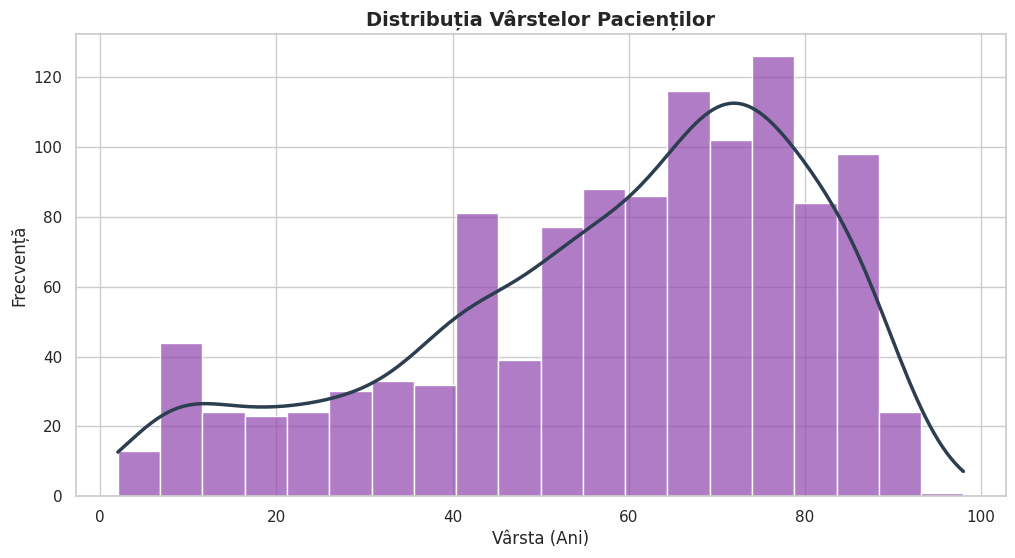

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", rc={"axes.titlesize": 14, "axes.labelsize": 12})

plt.figure(figsize=(7, 5))

custom_palette = {"M": "#2E86C1", "F": "#E74C3C"} 

ax = sns.countplot(
    data=df_final, 
    x='gen', 
    hue='gen',  
    palette=custom_palette, 
    legend=False 
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=12, fontweight='bold')

plt.title('Distribuția Pacienților pe Gen (2025)', fontweight='bold')
plt.ylabel('Număr Pacienți')
plt.show()

plt.figure(figsize=(12, 6))

sns.histplot(
    df_final['Varsta'], 
    bins=20, 
    kde=True, 
    color='#8E44AD', 
    edgecolor='white', 
    alpha=0.7 
)

plt.gca().lines[0].set_color('#2C3E50')
plt.gca().lines[0].set_linewidth(2.5)

plt.title('Distribuția Vârstelor Pacienților', fontweight='bold')
plt.xlabel('Vârsta (Ani)')
plt.ylabel('Frecvență')
plt.show()

**1. Analiza pe Gen (Graficul 1)**
*   **Observație:** Sunt mult mai multi pacienti femei (~650) decât bărbați (~480).
*   **Insight de Business:** Decizia de achiziție în familia tipică din România este luată adesea de femei (atât pentru ele, cât și programând copiii sau soții).
*   **Acțiune:** Campaniile de marketing pe Facebook/Instagram ar trebui să aibă vizualuri orientate către femei ("Fashion", "Rame de brand").

**2. Analiza pe Vârstă (Graficul 2)**. 
Observam 3 maxime locale:
*   **Vârful 1 (Copii/Adolescenți 8-15 ani):** Primul varf, mai mic, din stanga. Aceștia sunt școlarii cu miopie (acest segment depinde de parinti).
*   **Categoria ~ 20-40 ani:** Se observa o scădere semnificativă aici. Oamenii tineri/adulți vin mai rar.
    *  Aici e o oportunitate de creștere (de ex: ochelari de protecție PC).
*   **Varful 2 ~ 40-45 ani:** Se observa inca un varf pe un interval mai scurt, reprezentand segmentul adultilor de varsta mijlocie.    
*   **Vârful 3 (Seniori 60-80 ani):** Vârful masiv din dreapta. Aceștia sunt pacienții cu patologii (cataractă, glaucom) și prezbiopie.
*   **Insight de business**: Aceștia sunt clienții fideli și care au nevoie de tratamente scumpe/complexe.

In [6]:
profil_gen = df_final.groupby('gen').agg({
    'Varsta': 'mean',                  # Vârsta medie
    'Nr. programari ratate': 'sum',    # Total ratări
    'gen': 'count'                     # Numărul de pacienți (ca să știm câți sunt)
}).rename(columns={'Sex': 'Nr_Pacienti'})

print("Tabel Agregat - Profil pe Gen:")
display(profil_gen)

df_final['Deceniu_Varsta'] = (df_final['Varsta'] // 10) * 10
raport_varsta = df_final.groupby('Deceniu_Varsta')['Nr. programari ratate'].mean()

print("\nMedia programărilor ratate pe categorii de vârstă:")
display(raport_varsta)

df_final.to_csv('pacienti_procesat_2025.csv', index=False)
profil_gen.to_excel('raport_sumar_gen.xlsx')

print("Fișierele 'pacienti_procesat_2025.csv' și 'raport_sumar_gen.xlsx' au fost salvate.")

Tabel Agregat - Profil pe Gen:


,Varsta,Nr. programari ratate,gen
gen,,,
F,59.503794,1825,659
M,56.565844,912,486



Media programărilor ratate pe categorii de vârstă:


Deceniu_Varsta
0     3.720000
10    1.043478
20    1.222222
30    1.147059
40    6.568000
50    2.139394
60    1.198020
70    1.212245
80    3.627907
90    1.222222
Name: Nr. programari ratate, dtype: float64

Fișierele 'pacienti_procesat_2025.csv' și 'raport_sumar_gen.xlsx' au fost salvate.


In [7]:
import gspread_dataframe as gd

WAREHOUSE_SHEET_ID = '1AqNlegU_wTy5HpEcf1ThwOfe8K_81rGoPIvByGPK6RI'

def push_data_to_looker_source(dataframe, sheet_id, worksheet_name):
    try:
        sh = client.open_by_key(sheet_id)
        
        try:
            worksheet = sh.worksheet(worksheet_name)
        except:
            print(f"Foaia '{worksheet_name}' nu există. O creez acum.")
            worksheet = sh.add_worksheet(title=worksheet_name, rows="1000", cols="20")
            
        worksheet.clear()
        gd.set_with_dataframe(worksheet, dataframe)
        
        print(f"Succes! Datele au fost actualizate în foaia '{worksheet_name}'.")
        
    except Exception as e:
        print(f"Eroare la upload: {e}")

push_data_to_looker_source(df_final, WAREHOUSE_SHEET_ID, 'Main_Pacienti')

push_data_to_looker_source(profil_gen, WAREHOUSE_SHEET_ID, 'Agg_Gender_Stats')

Foaia 'Main_Pacienti' nu există. O creez acum.
Succes! Datele au fost actualizate în foaia 'Main_Pacienti'.
Foaia 'Agg_Gender_Stats' nu există. O creez acum.
Succes! Datele au fost actualizate în foaia 'Agg_Gender_Stats'.
